# Fake, Real and AI-Generated News Detection
### [CM3070] Final Project, NLP Fake News Detection Template

## 1. Project Setup
Let's start with importing the necessary libraries and the three datasets to be used in this project, the 'Fake and Real News' Kaggle dataset, the LIAR dataset and the GPT2-output dataset.

### 1.1 Importing Libraries and Tools

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt #Plotting properties
import seaborn as sns
# Set style for seaborn for better readability
sns.set(style="whitegrid")
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')  # For WordNet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Show all matplotlib graphs inline
%matplotlib inline

[nltk_data] Downloading package stopwords to /Users/yassu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/yassu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/yassu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


### 1.2 Import GPT2-output Dataset

In [5]:
import os
import sys
import requests
from tqdm import tqdm
import re

In [6]:
# subdir = 'data'
# if not os.path.exists(subdir):
#     os.makedirs(subdir)
# subdir = subdir.replace('\\','/') # needed for Windows


# # Just downloading outputs from strongest version (xl-1542M)

# # The dataset contains train, valid and test sets, but the number of samples
# # is so large that we only need the training set (250,000 samples)
# filename = 'xl-1542M-k40.train.jsonl'
# r = requests.get("https://openaipublic.azureedge.net/gpt-2/output-dataset/v1/" + filename, stream=True)

# with open(os.path.join(subdir, filename), 'wb') as f:
#     file_size = int(r.headers["content-length"])
#     chunk_size = 1000
#     with tqdm(ncols=100, desc="Fetching " + filename, total=file_size, unit_scale=True) as pbar:
#         # 1k for chunk_size, since Ethernet packet size is around 1500 bytes
#         for chunk in r.iter_content(chunk_size=chunk_size):
#             f.write(chunk)
#             pbar.update(chunk_size)

In [7]:
# ai_df = pd.read_json('data/xl-1542M-k40.train.jsonl', lines=True)

In [8]:
# ai_df.to_csv('data/gpt2_output.csv', index=False)

In [9]:
gpt2_df = pd.read_csv('data/gpt2_output.csv')

In [10]:
# Confirm length is correct (250,000 expected)
print("Number of AI text articles: " + str(len(gpt2_df)))

Number of AI text articles: 250000


In [11]:
gpt2_df.head()

,id,text,length,ended
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True
1,2,The latest edition of the German Football Hall...,715,True
2,3,"Dangerous animals, especially snakes, in a car...",1024,False
3,4,I started my first MLP story way back in 2014 ...,1024,False
4,5,This article is a disambiguation page for The ...,84,True


In [12]:
# Printing first output
gpt2_df.iloc[0, 1]

'Cops will have to take "extreme care" to avoid jail-breaking the latest iPhones as the US government will fine manufacturers for breaking its digital security.\n\nApple has been criticised for designing and releasing its latest smartphone without any security measures.\n\nApple has defended the iPhone 6 for carrying out some of its advanced security measures, but will be fined if it continues to fail that test.\n\nThe Federal Communications Commission and FBI will be allowed to fine companies as much as $25,000 (£17,800) for not patching bugs after they are announced.\n\nThe FCC, under a new ruling from president Obama , will allow fines of $1,500 per device over the same "bug bounty".\n\nThere have been multiple hacks into iPhone 6 smartphones this year in the wake of the 2013 revelation that the device could be unlocked with a passcode lock.\n\nHowever, security experts have criticised Apple\'s software and device for not patching its bugs to prevent them becoming the latest weapon 

### 1.3 Import the 'Fake and Real News' Kaggle Dataset

In [14]:
# Load Kaggle Dataset (Real vs. Fake News)
real_news = pd.read_csv('data/True.csv')
fake_news = pd.read_csv('data/Fake.csv')

In [15]:
real_news.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [16]:
fake_news.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


### 1.4 Import the LIAR Dataset

In [18]:
# Load LIAR dataset
# Import the LIAR dataset without headers
columns = ["id", "label", "statement", "subject", "speaker", "job_title", "state", 
           "party", "barely_true_count", "false_count", "half_true_count", 
           "mostly_true_count", "pants_fire_count", "context"]

liar_train = pd.read_csv("data/train.tsv", sep='\t', header=None, names=columns)  # LIAR is tab-separated
liar_test = pd.read_csv("data/test.tsv", sep='\t', header=None, names=columns)
liar_valid = pd.read_csv("data/valid.tsv", sep='\t', header=None, names=columns)

In [19]:
liar_train.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [20]:
liar_test.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video


In [21]:
liar_valid.head()

,id,label,statement,subject,speaker,job_title,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,12134.json,barely-true,We have less Americans working now than in the...,"economy,jobs",vicky-hartzler,U.S. Representative,Missouri,republican,1,0,1,0,0,an interview with ABC17 News
1,238.json,pants-fire,"When Obama was sworn into office, he DID NOT u...","obama-birth-certificate,religion",chain-email,NaN,NaN,none,11,43,8,5,105,NaN
2,7891.json,false,Says Having organizations parading as being so...,"campaign-finance,congress,taxes",earl-blumenauer,U.S. representative,Oregon,democrat,0,1,1,1,0,a U.S. Ways and Means hearing
3,8169.json,half-true,Says nearly half of Oregons children are poor.,poverty,jim-francesconi,Member of the State Board of Higher Education,Oregon,none,0,1,1,1,0,an opinion article
4,929.json,half-true,On attacks by Republicans that various program...,"economy,stimulus",barack-obama,President,Illinois,democrat,70,71,160,163,9,interview with CBS News


## 2. Data Pre-processing and Cleaning
After all the datasets have been imported, we will go into pre-processing and cleaning them.

### 2.1 Pre-processing the 'Fake and Real News' Kaggle Dataset

In [24]:
# combining true and fake dataframes and adding a column for labels
fake_news['label'] = 'fake'
real_news['label'] = 'real'
news_df = pd.concat([fake_news, real_news], ignore_index=True)

In [25]:
news_df = news_df.drop_duplicates(subset='text').reset_index(drop=True)

In [26]:
news_df = news_df.dropna(subset=['text'])

In [27]:
# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove special characters and numbers, keep only letters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Convert text to lowercase
    text = text.lower()
    # Tokenize text into words
    words = text.split()
    # Remove stopwords and lemmatize each word
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Rejoin the words into a single string
    return " ".join(words)

In [28]:
news_df['cleaned_text'] = news_df['text'].apply(clean_text)

In [29]:
news_df.head()

,title,text,subject,date,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake,pope francis used annual christmas day message...


In [30]:
news_df.tail()

,title,text,subject,date,label,cleaned_text
38641,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",real,brussels reuters nato ally tuesday welcomed pr...
38642,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",real,london reuters lexisnexis provider legal regul...
38643,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",real,minsk reuters shadow disused sovietera factory...
38644,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",real,moscow reuters vatican secretary state cardina...
38645,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",real,jakarta reuters indonesia buy sukhoi fighter j...


In [31]:
news_df.drop(['date', 'text', 'subject'], axis=1, inplace=True)

In [32]:
news_df.head()

,title,label,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,fake,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,fake,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,fake,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,fake,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,fake,pope francis used annual christmas day message...


In [33]:
news_df = news_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [34]:
news_df.drop(['title'], axis=1, inplace=True)

In [35]:
news_df = news_df[["text", "label"]]

In [36]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


### 2.2 Pre-processing the LIAR Dataset

In [38]:
# Drop unnecessary columns
columns_to_keep = ["label", "statement"]
liar_train = liar_train[columns_to_keep]
liar_test = liar_test[columns_to_keep]
liar_valid = liar_valid[columns_to_keep]

In [39]:
liar_valid.head()

,label,statement
0,barely-true,We have less Americans working now than in the...
1,pants-fire,"When Obama was sworn into office, he DID NOT u..."
2,false,Says Having organizations parading as being so...
3,half-true,Says nearly half of Oregons children are poor.
4,half-true,On attacks by Republicans that various program...


In [40]:
liar_test.head()

,label,statement
0,true,Building a wall on the U.S.-Mexico border will...
1,false,Wisconsin is on pace to double the number of l...
2,false,Says John McCain has done nothing to help the ...
3,half-true,Suzanne Bonamici supports a plan that will cut...
4,pants-fire,When asked by a reporter whether hes at the ce...


In [41]:
liar_train.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [42]:
liar_df = pd.concat([liar_train, liar_test, liar_valid], ignore_index=True)

In [43]:
liar_df.head()

,label,statement
0,false,Says the Annies List political group supports ...
1,half-true,When did the decline of coal start? It started...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo..."
3,false,Health care reform legislation is likely to ma...
4,half-true,The economic turnaround started at the end of ...


In [44]:
liar_df.tail()

,label,statement
12786,half-true,"For the first time in more than a decade, impo..."
12787,mostly-true,Says Donald Trump has bankrupted his companies...
12788,true,"John McCain and George Bush have ""absolutely n..."
12789,false,A new poll shows 62 percent support the presid...
12790,barely-true,No one claims the report vindicating New Jerse...


In [45]:
# Shuffle the data to ensure randomness
liar_df = liar_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [46]:
def simplify_label(label):
    if label in ['false', 'pants-fire', 'barely-true']:
        return 'fake'
    else:
        return 'real'

liar_df['label'] = liar_df['label'].apply(simplify_label)

In [47]:
liar_df.head()

,label,statement
0,fake,"In the event of a U.S. strike on Syria, the Ru..."
1,real,To give the proposed economic stimulus plan so...
2,fake,Its warmer on Mars than it is in parts of the ...
3,real,The health insurance plan that (members of Con...
4,fake,He's promising four more years of an administr...


In [48]:
liar_df.describe()

,label,statement
count,12791,12791
unique,2,12765
top,real,On changing the rules for filibusters on presi...
freq,7134,3


In [49]:
liar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12791 entries, 0 to 12790
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      12791 non-null  object
 1   statement  12791 non-null  object
dtypes: object(2)
memory usage: 200.0+ KB


In [50]:
liar_df['cleaned_text'] = liar_df['statement'].apply(clean_text)

In [51]:
liar_df = liar_df.rename(columns={"cleaned_text": "text", "label": "label"})

In [52]:
liar_df.drop(['statement'], axis=1, inplace=True)

In [53]:
liar_df = liar_df[["text", "label"]]

In [54]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


### 2.3 Pre-processing the GPT2-output Dataset

In [56]:
gpt2_df["label"] = "AI-generated"

In [57]:
gpt2_df.head()

,id,text,length,ended,label
0,1,"Cops will have to take ""extreme care"" to avoid...",433,True,AI-generated
1,2,The latest edition of the German Football Hall...,715,True,AI-generated
2,3,"Dangerous animals, especially snakes, in a car...",1024,False,AI-generated
3,4,I started my first MLP story way back in 2014 ...,1024,False,AI-generated
4,5,This article is a disambiguation page for The ...,84,True,AI-generated


In [58]:
gpt2_df.drop(['id', 'length', 'ended'], axis=1, inplace=True)

In [59]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [60]:
# Remove duplicates and handle missing values
gpt2_df.drop_duplicates(subset="text", inplace=True)
gpt2_df.dropna(subset=["text"], inplace=True)

In [61]:
gpt2_df.head()

,text,label
0,"Cops will have to take ""extreme care"" to avoid...",AI-generated
1,The latest edition of the German Football Hall...,AI-generated
2,"Dangerous animals, especially snakes, in a car...",AI-generated
3,I started my first MLP story way back in 2014 ...,AI-generated
4,This article is a disambiguation page for The ...,AI-generated


In [62]:
gpt2_df['text'] = gpt2_df['text'].apply(clean_text)

In [63]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


### 2.4 Checking All the Datasets

In [65]:
news_df.head()

,text,label
0,donald trump wish american happy new year leav...,fake
1,house intelligence committee chairman devin nu...,fake
2,friday revealed former milwaukee sheriff david...,fake
3,christmas day donald trump announced would bac...,fake
4,pope francis used annual christmas day message...,fake


In [66]:
liar_df.head()

,text,label
0,event u strike syria russian replace weapon im...,fake
1,give proposed economic stimulus plan perspecti...,real
2,warmer mar part united state canada polar vortex,fake
3,health insurance plan member congress differen...,real
4,he promising four year administration push pri...,fake


In [67]:
gpt2_df.head()

,text,label
0,cop take extreme care avoid jailbreaking lates...,AI-generated
1,latest edition german football hall fame ballo...,AI-generated
2,dangerous animal especially snake car safety h...,AI-generated
3,started first mlp story way back joke well rea...,AI-generated
4,article disambiguation page big apple followin...,AI-generated


In [68]:
news_df.tail()

,text,label
38641,brussels reuters nato ally tuesday welcomed pr...,real
38642,london reuters lexisnexis provider legal regul...,real
38643,minsk reuters shadow disused sovietera factory...,real
38644,moscow reuters vatican secretary state cardina...,real
38645,jakarta reuters indonesia buy sukhoi fighter j...,real


In [69]:
liar_df.tail()

,text,label
12786,say opponent health care law prevailed two mai...,real
12787,mosque near ground zero,real
12788,louie gohmert texas blamed mass shooting movie...,fake
12789,governor consult member party released transpo...,fake
12790,telecom bill could keep state corporation comm...,fake


In [70]:
gpt2_df.tail()

,text,label
249995,lot thing dont like job cooped office long hou...,AI-generated
249996,year unprecedented public outcry use water pun...,AI-generated
249997,battle english scot english victory flodden ki...,AI-generated
249998,kurt rambis new head coach knicks kurt rambis ...,AI-generated
249999,leader need thats differ new president united ...,AI-generated


In [71]:
# saving all cleaned dataframes to CSV files.
news_df.to_csv('data/news.csv', index=False)
liar_df.to_csv('data/liar.csv', index=False)
gpt2_df.to_csv('data/gpt2.csv', index=False)

In [72]:
news_df["label"].value_counts()

label
real    21191
fake    17455
Name: count, dtype: int64

In [73]:
liar_df["label"].value_counts()

label
real    7134
fake    5657
Name: count, dtype: int64

In [74]:
gpt2_df["label"].value_counts()

label
AI-generated    249796
Name: count, dtype: int64

### 2.4 Downsampling the GPT-2-output Dataset
The GPT-2 output dataset is about 250000 values which need to be downsamlped to avoid data imbalance and model bias.

In [76]:
gpt2_sampled = gpt2_df.sample(n=23000, random_state=42)

### 2.5 Downsampling the 'real' samples in LIAR and Kaggle Datasets
This reduces bias from the overrepresented real class while preserving the diversity of text samples, because real has significantly more samples than fake in news_df and liar_df.

In [78]:
# Downsample real class in news_df
real_downsampled = news_df[news_df['label'] == 'real'].sample(n=17455, random_state=42)
fake = news_df[news_df['label'] == 'fake']
balanced_news_df = pd.concat([real_downsampled, fake])

# Downsample real class in news_df
liar_real_downsampled = liar_df[liar_df['label'] == 'real'].sample(n=5657, random_state=42)
liar_fake = liar_df[liar_df['label'] == 'fake']
balanced_liar_df = pd.concat([liar_real_downsampled, liar_fake])

### 2.6 Merging the Datasets
After balancing, I will combine gpt2_df, balanced_news_df, and balanced_liar_df.

In [80]:
# Rename labels for consistency
gpt2_sampled['label'] = 'AI-generated'
balanced_news_df['label'] = balanced_news_df['label'].map({'real': 'real', 'fake': 'fake'})
balanced_liar_df['label'] = balanced_liar_df['label'].map({'real': 'real', 'fake': 'fake'})

# Merge datasets
merged_df = pd.concat([balanced_news_df, balanced_liar_df, gpt2_sampled])

In [81]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

### 2.7 Shuffling the dataset to mix samples from different sources.

In [83]:
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [84]:
merged_df['label'].value_counts()

label
real            23112
fake            23112
AI-generated    23000
Name: count, dtype: int64

In [85]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [86]:
merged_df.shape

(69224, 2)

In [87]:
merged_df.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

In [89]:
# Get basic info (data types, non-null counts)
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69224 entries, 0 to 69223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69224 non-null  object
 1   label   69224 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB
None


In [90]:
# Get statistical summary for numerical columns
print(merged_df.describe())

         text  label
count   69224  69224
unique  69035      3
top             real
freq       63  23112


In [91]:
# Check for null values
print(merged_df.isnull().sum())

text     0
label    0
dtype: int64


/var/folders/w5/1ych38yj6yj23h6z6t94wlz40000gn/T/ipykernel_5486/2695789455.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='label', palette='muted')


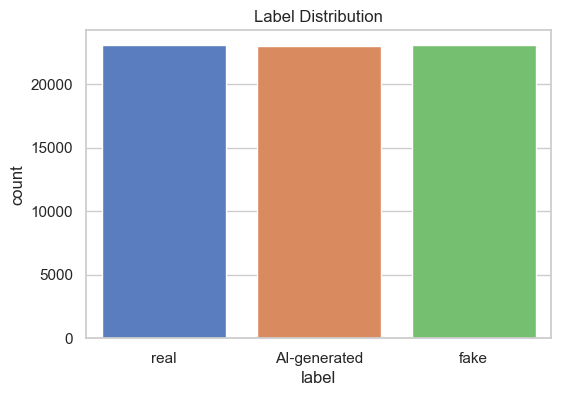

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=merged_df, x='label', palette='muted')
plt.title('Label Distribution')
plt.show()

/var/folders/w5/1ych38yj6yj23h6z6t94wlz40000gn/T/ipykernel_5486/2752930403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='label', y=merged_df['text'].apply(len), palette='muted')


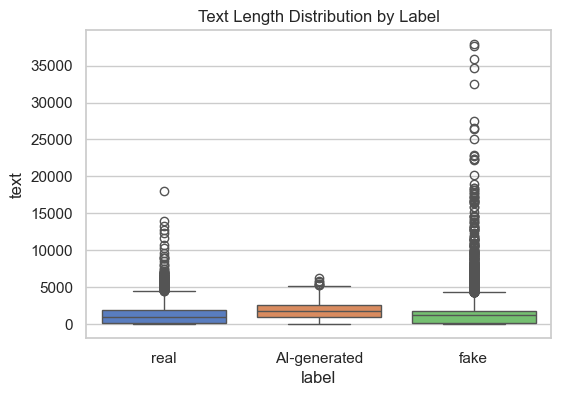

In [93]:
# Plot text length vs label
plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_df, x='label', y=merged_df['text'].apply(len), palette='muted')
plt.title('Text Length Distribution by Label')
plt.show()

In [94]:
# Check for duplicates in text and label columns
duplicates = merged_df.duplicated(subset=['text', 'label'])
print(f"Number of duplicate entries: {duplicates.sum()}")

Number of duplicate entries: 184


In [95]:
merged_df = merged_df.drop_duplicates(subset=['text', 'label'], keep='first')

In [96]:
merged_df['label'].value_counts()

label
fake            23031
real            23024
AI-generated    22985
Name: count, dtype: int64

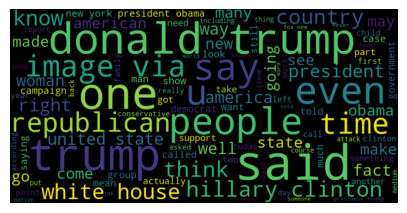

In [97]:
from wordcloud import WordCloud

wordcloud_text = ''.join(merged_df[merged_df['label']=='fake']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

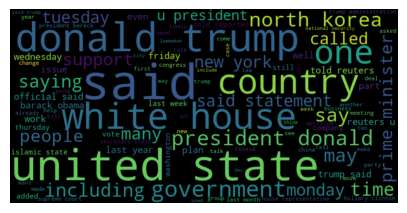

In [98]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='real']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

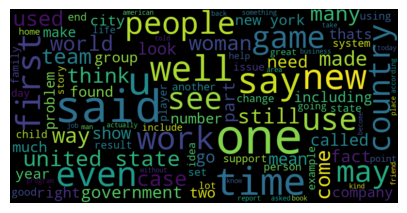

In [99]:
wordcloud_text = ''.join(merged_df[merged_df['label']=='AI-generated']['text'])
# Create the word cloud
wordcloud = WordCloud(max_font_size=100, max_words=100, width=800, height=400, background_color='black').generate(wordcloud_text)

# Display the word cloud
plt.figure(figsize=(5, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 4. Baseline Modeling
### 4.1 Data Splitting
Spliting the dataset into training, validation, and testing sets:
- Training Set: 64% of the data
- Validation Set: 16% of the data
- Testing Set: 20% of the data

In [101]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into 80% training and 20% testing.
train_df, test_df = train_test_split(merged_df, test_size=0.2, stratify=merged_df['label'], random_state=42)
# Then taking 20% of the 80% training data (16% of the original dataset) for validation.
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['label'], random_state=42)

### 4.2 Vectorization with TF-IDF

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [104]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=10_000)
X_train = vectorizer.fit_transform(train_df['text'])
X_val = vectorizer.transform(val_df['text'])
X_test = vectorizer.transform(test_df['text'])

If the labels are text strings ("fake", "real", "AI-generated"), they need to be encoded numerically for sklearn models. LabelEncoder or OneHotEncoder can be used.

In [106]:
# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

### 4.3 Training the Logistic Regression Model

In [108]:
# Model Training
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [109]:
# Validation Predictions
y_pred = model.predict(X_val)

## 5. Model Evaluation

In [111]:
# Print Accuracy Score
print(accuracy_score(y_val, y_pred))

0.8697383905132615


In [112]:
# Evaluation
print("Validation Metrics:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

Validation Metrics:
              precision    recall  f1-score   support

AI-generated       0.92      0.91      0.92      3678
        fake       0.84      0.84      0.84      3685
        real       0.85      0.86      0.86      3684

    accuracy                           0.87     11047
   macro avg       0.87      0.87      0.87     11047
weighted avg       0.87      0.87      0.87     11047



In [113]:
# Test Predictions
y_test_pred = model.predict(X_test)
print("Test Metrics:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

Test Metrics:
              precision    recall  f1-score   support

AI-generated       0.92      0.91      0.92      4597
        fake       0.85      0.85      0.85      4606
        real       0.86      0.87      0.86      4605

    accuracy                           0.88     13808
   macro avg       0.88      0.88      0.88     13808
weighted avg       0.88      0.88      0.88     13808



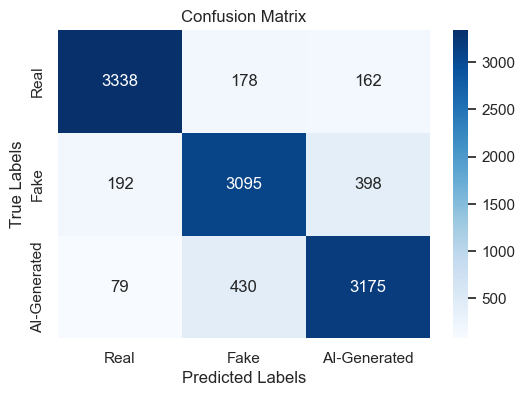

In [114]:
from sklearn.metrics import confusion_matrix

# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Investigating Different Methodologies
### 6. Word2Vec with Random Forest Classifier

In [116]:
# print percentage of each label
print(merged_df['label'].value_counts(normalize=True) * 100)

label
fake            33.358922
real            33.348783
AI-generated    33.292294
Name: proportion, dtype: float64


In [117]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [118]:
merged_df.head(5)

,text,label,tokenized_text
0,berlin reuters turkey summoned germany ambassa...,real,"[berlin, reuters, turkey, summoned, germany, a..."
1,florida woman charged killing husband shot wou...,AI-generated,"[florida, woman, charged, killing, husband, sh..."
2,final day afghanistan president obama haunted ...,AI-generated,"[final, day, afghanistan, president, obama, ha..."
3,group grifter clinton scammer chelsea demand h...,fake,"[group, grifter, clinton, scammer, chelsea, de..."
4,republican front runner donald trump recently ...,fake,"[republican, front, runner, donald, trump, rec..."


In [119]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [120]:
from gensim.models import Word2Vec

# Train Word2Vec model
word2vec_model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, workers=4)

# Save the model for later use
word2vec_model.save("word2vec.model")

In [121]:
# Example: Access the vector for a specific word
example_vector = word2vec_model.wv["president"]

In [122]:
print(example_vector)

[ 0.5199276  -2.2993982  -1.7480034  -0.37818637  0.4680525   1.306247
 -0.33288872  0.16142793  0.8190403  -0.4270478   1.2424034  -0.6507907
  0.9961989  -0.8484402   2.3604598   1.3364207   1.7980174   3.0546863
 -2.3921328  -0.95288336 -3.0187962  -1.5176351   0.29134646 -2.5648773
 -0.3506302   2.483746   -2.6305797  -0.9250788   1.8911641   0.5072741
 -1.6686885  -0.38502452  0.518027   -0.28522918  1.343599   -0.43408257
 -0.2668279   1.0045342  -1.3249233   2.241402    3.1417623  -0.59856176
 -1.2355379  -1.0619279  -2.1872854   0.07813078  1.7192554  -0.1907871
 -1.1711279   0.8031023  -1.305498   -1.945964   -3.3147426  -1.0733408
  0.6041553   1.0795642   0.39840934 -2.6705897   2.8705206  -0.20945288
 -0.26396796 -2.3352652   0.3906669  -0.781809   -1.8018861  -0.8177898
 -1.921707    0.56362426  0.9311054  -0.22305988  4.2409306   1.1302083
 -1.2476168   1.824326    2.3071897   0.25979134  1.2507617   0.31121632
 -1.5408165   2.6184342   0.28947097  1.9972725   0.18185262 

In [123]:
merged_df.to_csv("processed_data.csv", index=False)

In [124]:
print(len(word2vec_model.wv.key_to_index))  # Number of words in the vocabulary

76462


In [125]:
print(word2vec_model.wv.most_similar("president"))  # Check related words

[('presidentelect', 0.7307779788970947), ('presidency', 0.6324501037597656), ('versa', 0.5800278782844543), ('presidentbiden', 0.5521736145019531), ('administration', 0.523861289024353), ('presidential', 0.5236548185348511), ('presidentthe', 0.5152905583381653), ('rumsfeld', 0.5099175572395325), ('commanderinchief', 0.5023128390312195), ('biden', 0.5017991662025452)]


In [126]:
print(word2vec_model.wv.most_similar("real", topn=5))

[('actual', 0.5981881022453308), ('sort', 0.5603285431861877), ('actually', 0.5532589554786682), ('obvious', 0.5450149178504944), ('simply', 0.528765082359314)]


### Since Random Forest expects fixed-length feature vectors, we need to aggregate the Word2Vec embeddings as follows:
- Averaging Word Embeddings: Computing the mean of the word embeddings for all words in a document.

In [128]:
# Compute the average embedding for a document
def compute_average_embedding(words, model, vector_size):
    valid_words = [word for word in words if word in model.wv]
    if len(valid_words) == 0:
        return np.zeros(vector_size)  # Handle empty documents
    return np.mean([model.wv[word] for word in valid_words], axis=0)

# Apply the function to tokenized text
vector_size = 100  # Same as used in Word2Vec model
merged_df['doc_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: compute_average_embedding(x, word2vec_model, vector_size)
)

In [129]:
# Extract features and labels
X = np.stack(merged_df['doc_embedding'].values)  # Convert embeddings to a NumPy array
y = merged_df['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [130]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [131]:
# Predict on the test set
y_pred = rf_classifier.predict(X_test)

In [132]:
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8145278099652375


In [133]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

AI-generated       0.88      0.82      0.85      4561
        fake       0.80      0.80      0.80      4649
        real       0.77      0.83      0.80      4598

    accuracy                           0.81     13808
   macro avg       0.82      0.81      0.82     13808
weighted avg       0.82      0.81      0.82     13808



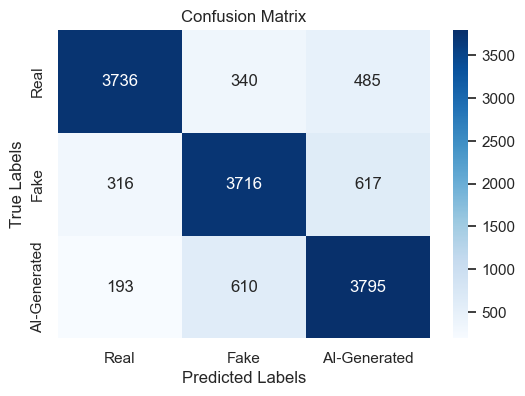

In [134]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [135]:
merged_df.tail(5)

,text,label,tokenized_text,doc_embedding
69219,dan patrick called increasing gas tax state sa...,real,"[dan, patrick, called, increasing, gas, tax, s...","[0.9832448, 0.28657922, 0.5517874, -0.84853536..."
69220,reuters national football league said tuesday ...,real,"[reuters, national, football, league, said, tu...","[0.23652075, 0.04091971, 0.23780872, -0.113401..."
69221,fort lauderdale fla drama come big trade baseb...,AI-generated,"[fort, lauderdale, fla, drama, come, big, trad...","[0.44134256, 0.3461017, 0.26515785, 0.28274885..."
69222,mexico city reuters former mexico finance mini...,real,"[mexico, city, reuters, former, mexico, financ...","[-0.32455385, 0.086333975, -0.4079418, -0.1722..."
69223,beirut reuters syria army ally encircled islam...,real,"[beirut, reuters, syria, army, ally, encircled...","[-0.8371847, -0.7124149, -0.49136382, -0.24737..."


### DistilBERT initial trial

In [137]:
pip install --upgrade transformers

Note: you may need to restart the kernel to use updated packages.


In [138]:
pip install transformers datasets torch

Note: you may need to restart the kernel to use updated packages.


In [139]:
pip install tf-keras

Note: you may need to restart the kernel to use updated packages.


In [140]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# Load tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [141]:
merged_df.head()

,text,label,tokenized_text,doc_embedding
0,berlin reuters turkey summoned germany ambassa...,real,"[berlin, reuters, turkey, summoned, germany, a...","[-0.8493773, -0.4141555, 0.12432378, -0.055907..."
1,florida woman charged killing husband shot wou...,AI-generated,"[florida, woman, charged, killing, husband, sh...","[0.31924003, 0.08847133, 0.27760875, 0.3720364..."
2,final day afghanistan president obama haunted ...,AI-generated,"[final, day, afghanistan, president, obama, ha...","[0.52635425, -0.06093629, -0.71548206, 0.24257..."
3,group grifter clinton scammer chelsea demand h...,fake,"[group, grifter, clinton, scammer, chelsea, de...","[0.10338436, -0.26960012, 0.18047726, 0.177603..."
4,republican front runner donald trump recently ...,fake,"[republican, front, runner, donald, trump, rec...","[-0.009196689, -0.38378498, -0.45697328, -0.34..."


In [142]:
merged_df.drop(['doc_embedding'], axis=1, inplace=True)

In [143]:
merged_df.drop(['tokenized_text'], axis=1, inplace=True)

In [144]:
merged_df.head()

,text,label
0,berlin reuters turkey summoned germany ambassa...,real
1,florida woman charged killing husband shot wou...,AI-generated
2,final day afghanistan president obama haunted ...,AI-generated
3,group grifter clinton scammer chelsea demand h...,fake
4,republican front runner donald trump recently ...,fake


In [145]:
from datasets import Dataset

# Convert your pandas DataFrame to a Hugging Face Dataset
dataset = Dataset.from_pandas(merged_df)

# Split the dataset into train and test sets
dataset = dataset.train_test_split(test_size=0.2)

train_dataset = dataset['train']
test_dataset = dataset['test']

In [146]:
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Remove unused columns and set format for PyTorch
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [147]:
pip install 'accelerate>=0.26.0'

Note: you may need to restart the kernel to use updated packages.


In [148]:
# Map the labels to numeric values
label_map = {'fake': 0, 'real': 1, 'AI-generated': 2}

train_dataset = train_dataset.map(lambda x: {'label': label_map[x['label']]})
test_dataset = test_dataset.map(lambda x: {'label': label_map[x['label']]})

Map:   0%|          | 0/55232 [00:00<?, ? examples/s]

Map:   0%|          | 0/13808 [00:00<?, ? examples/s]

In [149]:
from transformers import TrainingArguments, Trainer

# Define model
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train the model
trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Evaluate the model
trainer.evaluate()

In [ ]:
# Save model for later use
model.save_pretrained("./distilbert-finetuned")
tokenizer.save_pretrained("./distilbert-finetuned")

In [ ]:
# Get predictions and true labels from the trainer
predictions = trainer.predict(test_dataset)
pred_labels = predictions.predictions.argmax(axis=-1)
true_labels = test_dataset['label']

In [ ]:
# Evaluate performance
print("Accuracy:", accuracy_score(true_labels, pred_labels))

In [ ]:
print("Classification Report:\n", classification_report(true_labels, pred_labels))

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Optuna Hyperparameter Tuning

In [ ]:
import optuna
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score

# Define a function to compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# Define the objective function for Optuna
def objective(trial):
    # Define hyperparameters to tune
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
    num_train_epochs = trial.suggest_int("num_train_epochs", 2, 5)
    weight_decay = trial.suggest_float("weight_decay", 0.01, 0.1)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=16,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        logging_dir="./logs",
        save_strategy="no",  # Disable saving checkpoints to save disk space
        report_to="none",  # Disable logging to external services
        load_best_model_at_end=False,  # Disable loading the best model at the end
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,  # Add the compute_metrics function
    )

    # Train the model
    trainer.train()
    
    # Evaluate the model
    eval_results = trainer.evaluate()

    # Extract the accuracy metric
    accuracy = eval_results.get("eval_accuracy")
    if accuracy is None:
        raise ValueError("Evaluation did not return an accuracy metric.")

    return accuracy

In [ ]:
# Initialize Optuna study
study = optuna.create_study(direction="maximize")

In [ ]:
# Start optimization
study.optimize(objective, n_trials=10)

In [ ]:
# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

In [ ]:
# Print best accuracy
print("Best accuracy:", study.best_value)

## RNNs Trial

Next we will test RNNs and see if they perform better than DistilBERT.

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
# encode the labels to integers
label_encoder = LabelEncoder()
merged_df['label_encoded'] = label_encoder.fit_transform(merged_df['label'])  # Convert labels to integers
num_classes = len(label_encoder.classes_)  # Number of unique labels

In [ ]:
# prepare train and test splits
X = merged_df['text']
y = to_categorical(merged_df['label_encoded'], num_classes=num_classes)  # One-hot encode the labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Tokenize and pad sequences
max_words = 5000  # Vocabulary size
max_len = 150  # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len)

In [ ]:
# define the RNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, BatchNormalization, Dropout, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam

vocab_size = 10000
embedding_dim = 128

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

rnn_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Compile the model
rnn_model.summary()
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Multiclass loss function
    metrics=['accuracy']
)
rnn_model.summary()

In [ ]:
# Train the model
history = rnn_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

In [ ]:
test_loss, test_accuracy = rnn_model.evaluate(X_test_padded, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Save the model for future use
rnn_model.save("rnn_model.keras")

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(X_test_padded, y_test)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## RNNs Tuning based on accuracy & loss graphs
changed learning rate from 0.001 to 0.0001, added two dropouts and lstm layers, increased lstm layers, accuracy: 87,42%

will try a new approach to RNNs LSTM and see the results
## ٍRNNs with Word2Vec

In [ ]:
# Pad sequences with Word2Vec embeddings
def get_sequence_embedding(tokens, model, vector_size, max_seq_len):
    sequence = []
    for word in tokens[:max_seq_len]:  # Truncate to max sequence length
        if word in model.wv:
            sequence.append(model.wv[word])
        else:
            sequence.append(np.zeros(vector_size))  # Handle OOV words
    # Pad sequence if it's shorter than max_seq_len
    while len(sequence) < max_seq_len:
        sequence.append(np.zeros(vector_size))
    return np.array(sequence)

In [ ]:
# Retokenizing the text into lists of words
merged_df['tokenized_text'] = merged_df['text'].apply(lambda x: x.split())

In [ ]:
# Extract tokenized sentences as a list of lists
tokenized_data = merged_df['tokenized_text'].tolist()

In [ ]:
# Define maximum sequence length for LSTM and vector size
max_seq_len = 150
vector_size = 100

# Compute sequence embeddings for each document
merged_df['sequence_embedding'] = merged_df['tokenized_text'].apply(
    lambda x: get_sequence_embedding(x, word2vec_model, vector_size, max_seq_len)
)

In [ ]:
# Stack the sequences correctly for LSTM input
X = np.array(list(merged_df['sequence_embedding'].values))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set shape for LSTM: {X_train.shape}")

In [ ]:
print(f"Expected shape: (samples, timesteps, features) -> {X_train.shape[0], max_seq_len, vector_size}")

In [ ]:
# Load the Word2Vec embeddings
embedding_matrix = np.zeros((len(word2vec_model.wv), vector_size))
word_index = {word: idx for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word_index.items():
    embedding_matrix[idx] = word2vec_model.wv[word]

In [ ]:
# Build the RNN model
lstm_model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, input_shape=(max_seq_len, vector_size))),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [ ]:
# Compile the model
lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
print(lstm_model.summary())

In [ ]:
# train the model
history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

In [ ]:
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(X_test, y_test)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the model for future use
rnn_model.save("lstm_model.keras")

## RNNs with GloVe Embeddings.
The dataset is already tokenized and preprocessed. Now, we need to:
- Load pre-trained GloVe embeddings.
- Create an embedding matrix for your vocabulary.
- Convert your tokenized text into sequences of GloVe embeddings.

In [ ]:
import torch

# Load GloVe embeddings
def load_glove_embeddings(glove_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

glove_path = "GloVe_embeddings/glove.6B.100d.txt"  # Path to GloVe file
glove_embeddings = load_glove_embeddings(glove_path)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize and pad the sequences
X = tokenizer.texts_to_sequences(merged_df['text'])
X = pad_sequences(X, maxlen=150)

# One-hot encode the labels
y = pd.get_dummies(merged_df['label']).values

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
# Map GloVe embeddings for each token in the sequences
X_embedded = np.zeros((len(X), max_seq_len, embedding_dim))
for i, seq in enumerate(X):
    for j, word_index in enumerate(seq):
        if word_index != 0:  # Skip padding
            word = tokenizer.index_word[word_index]
            embedding_vector = glove_embeddings.get(word)
            if embedding_vector is not None:
                X_embedded[i, j] = embedding_vector

In [ ]:
glove_lstm_model = Sequential([
    # Use the pretrained GloVe embeddings with non-trainable weights
    Embedding(input_dim=vocab_size, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix],
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

glove_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

glove_lstm_model.summary()

In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
# Train the model
glove_lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = glove_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(X_test, y_test)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs LSTM with FastText

In [ ]:
pip install fasttext

In [ ]:
pip install gensim

In [ ]:
merged_df.head(5)

In [ ]:
from gensim.models import FastText

# Tokenized text for training FastText
tokenized_texts = merged_df['tokenized_text']  # Assuming pre-tokenized list of lists

# Train FastText model
fasttext_model = FastText(sentences=tokenized_texts, 
                           vector_size=100, 
                           window=5, 
                           min_count=3, 
                           workers=4)

# Save the trained FastText model for future use
fasttext_model.save("fasttext.model")

In [ ]:
# Define max vocab size
max_vocab_size = 40000
embedding_dim = 100

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(merged_df['text'])

# Initialize embedding matrix
vocab_size = min(max_vocab_size, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Populate the embedding matrix with FastText vectors
for word, index in tokenizer.word_index.items():
    if index >= max_vocab_size:
        continue
    if word in fasttext_model.wv:
        embedding_matrix[index] = fasttext_model.wv[word]

In [ ]:
fasttext_lstm_model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes: real, fake, AI-generated
])

fasttext_lstm_model.compile(optimizer=Adam(learning_rate=0.0001),
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])

fasttext_lstm_model.summary()

In [ ]:
fasttext_lstm_model.fit(X_train, y_train, 
                        epochs=20, 
                        batch_size=64, 
                        validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = fasttext_lstm_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(X_test, y_test)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RNNs with CNNs layers.
Combining CNN and RNN layers is a powerful approach for text classification tasks, where CNNs capture local patterns, and RNNs handle sequential dependencies. 

In [ ]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

# Define the hybrid model
hybrid_model = Sequential([
    # Embedding layer with pre-trained FastText embeddings
    Embedding(input_dim=vocab_size, 
              output_dim=embedding_dim, 
              weights=[embedding_matrix],
              trainable=False),

    # CNN layers for feature extraction
    Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    BatchNormalization(),
    
    # RNN layers for sequence modeling
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    BatchNormalization(),
    Dropout(0.5),

    # Fully connected layers for classification
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # Three classes: real, fake, AI-generated
])

In [ ]:
# Compile the model
hybrid_model.compile(optimizer=Adam(learning_rate=0.0001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

In [ ]:
hybrid_model.summary()

In [ ]:
# Fit the model
hybrid_model.fit(X_train, y_train, 
                  epochs=10, 
                  batch_size=32, 
                  validation_data=(X_test, y_test))

In [ ]:
test_loss, test_accuracy = hybrid_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [ ]:
# Define the label names
labels = ['Real', 'Fake', 'AI-Generated']

# Compute confusion matrix
cm = confusion_matrix(X_test, y_test)

# Plot confusion matrix with clearer labels
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## RoBERTa Trial